# Stage 4: RL LOD Policy Training — REINFORCE

Trains a Gaussian policy network on rollout CSVs collected by `RLRolloutLogger` (rule-based fallback mode).  
Exports an ONNX model consumed by `RLPolicyController` and a `rl_scaler_constants.json` for `RLFeatureExtractor`.

**Input**: `rollout_ep*.csv` files from `data/Baker_Eval_3/`  
**Output**: `models/Stage_4/rl_policy_stage4.onnx` + `rl_scaler_constants.json`

### Feature order (must match `RLFeatureExtractor.ExpectedFeatureNames` exactly)
| idx | name | notes |
|-----|------|-------|
| 0 | cpu_frame_time | ms — diagnostic only |
| 1 | gpu_frame_time | ms — reward signal source |
| 2 | fps | 1/deltaTime |
| 3 | visible_renderer_count | frustum sweep, not URP profiler |
| 4 | triangle_count | profiler recorder |
| 5 | draw_call_count | profiler recorder |
| 6 | camera_speed | m/s |
| 7 | camera_rotation_speed | deg/s |
| 8 | avg_screen_coverage | SSIM proxy |
| 9 | previous_bias | lodBias prior frame |
| 10 | recent_lod_switch_count | ring buffer count |

### Reward formula (matches `RLRolloutLogger` header comment)
```
r_t = -alpha * ((gpu_ms - T_TARGET) / T_TARGET)^2
      - beta  * (1 - avg_screen_coverage)
      - gamma * (recent_lod_switch_count / N_MAX)
```

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sympy==1.12', 'optuna', '--quiet'])
print('Dependencies OK')

Dependencies OK


In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
BASE_DIR  = Path('../..').resolve()
DATA_DIR  = BASE_DIR / 'data' / 'Baker_Eval_3'
MODEL_DIR = BASE_DIR / 'models' / 'Stage_4'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_4' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Reward weights — must match RLEvaluationLogger inspector values
ALPHA     = 1.0
BETA      = 0.5
GAMMA_W   = 0.2
T_TARGET  = 4.5   # ms — VAR_T_TARGET_MS
N_MAX     = 30.0  # matches lodSwitchWindow in RLFeatureExtractor

# REINFORCE
GAMMA_RL  = 0.99  # discount factor
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Feature columns — order MUST match RLFeatureExtractor.ExpectedFeatureNames
FEATURE_COLS = [
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count',
]
FEATURE_COUNT = len(FEATURE_COLS)
assert FEATURE_COUNT == 11, 'Feature count must be 11'

print(f'DATA_DIR : {DATA_DIR}')
print(f'MODEL_DIR: {MODEL_DIR}')
print(f'PLOTS_DIR: {PLOTS_DIR}')

DATA_DIR : C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_Eval_3
MODEL_DIR: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4
PLOTS_DIR: C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_4\Train


## 1. Load Rollout CSVs
Reads `rollout_ep*.csv` files produced by `RLRolloutLogger`.  
Run the Unity scene in rule-based mode first if no files are found here.

In [4]:
# load rollouts — falls back to inference_eval_*.csv if no rollout_ep*.csv found
rollout_files = sorted(DATA_DIR.glob('rollout_ep*.csv'))
fallback_files = sorted(DATA_DIR.glob('inference_eval_*.csv'))

print(f'rollout_ep*.csv    : {len(rollout_files)}')
print(f'inference_eval*.csv: {len(fallback_files)}')

USING_FALLBACK = False
dfs = []

if rollout_files:
    # native Stage 4 rollout format
    for f in rollout_files:
        df = pd.read_csv(f)
        df['source_file'] = f.name
        dfs.append(df)

elif fallback_files:
    # remap Stage 3 inference_eval columns to Stage 4 rollout schema
    USING_FALLBACK = True
    print('WARNING: No rollout_ep*.csv found. Remapping inference_eval_*.csv as fallback.')
    print('Missing features (visible_renderer_count, triangle_count, etc.) will be zero.')
    print('These zero-filled features will produce a valid scaler but with low information.')
    print('Collect real rollout_ep*.csv from Unity rule-based mode for best results.\n')

    for ep_idx, f in enumerate(fallback_files):
        df = pd.read_csv(f)
        mapped = pd.DataFrame()
        mapped['episode']                = ep_idx
        mapped['step']                   = df['frame'] if 'frame' in df.columns else range(len(df))
        mapped['cpu_frame_time']         = pd.to_numeric(df.get('cpu_ms',   df.get('cpu_frame_time',  0)), errors='coerce')
        mapped['gpu_frame_time']         = pd.to_numeric(df.get('gpu_ms',   df.get('gpu_frame_time',  0)), errors='coerce')
        mapped['fps']                    = pd.to_numeric(df.get('fps', 60),  errors='coerce')
        mapped['visible_renderer_count'] = 0.0   # not logged in Stage 3 eval
        mapped['triangle_count']         = 0.0
        mapped['draw_call_count']        = 0.0
        mapped['camera_speed']           = 0.0
        mapped['camera_rotation_speed']  = 0.0
        mapped['avg_screen_coverage']    = 0.0
        mapped['previous_bias']          = pd.to_numeric(df.get('lod_bias_applied', 1.0), errors='coerce')
        mapped['recent_lod_switch_count']= 0.0
        mapped['lod_bias_before_action'] = mapped['previous_bias']
        mapped['action_delta']           = 0.0   # no action recorded in eval files
        mapped['lod_bias_after_action']  = mapped['previous_bias']
        mapped['source_file']            = f.name
        dfs.append(mapped)

else:
    raise FileNotFoundError(
        f'No rollout_ep*.csv or inference_eval_*.csv found in {DATA_DIR}.\n'
        'Run Unity with RLPolicyController (rule-based, ONNX field empty) '
        'and copy rollout_ep*.csv here.'
    )

raw = pd.concat(dfs, ignore_index=True)

# cast numerics
all_cols = ['episode', 'step', 'cpu_frame_time', 'gpu_frame_time', 'fps',
            'visible_renderer_count', 'triangle_count', 'draw_call_count',
            'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
            'previous_bias', 'recent_lod_switch_count',
            'lod_bias_before_action', 'action_delta', 'lod_bias_after_action']
for col in all_cols:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')

print(f'Raw rows: {len(raw):,} | Episodes: {raw["episode"].nunique()} | '
      f'Steps/ep: {raw.groupby("episode").size().mean():.0f}')
if USING_FALLBACK:
    print('NOTE: action_delta is all-zero — REINFORCE will train on zero-action behavior.')
    print('The scaler will be valid but 5 features will have zero variance (flagged in Section 3).')
raw.head(3)

rollout_ep*.csv    : 0
inference_eval*.csv: 2
Missing features (visible_renderer_count, triangle_count, etc.) will be zero.
These zero-filled features will produce a valid scaler but with low information.
Collect real rollout_ep*.csv from Unity rule-based mode for best results.

Raw rows: 8,023 | Episodes: 0 | Steps/ep: nan
NOTE: action_delta is all-zero — REINFORCE will train on zero-action behavior.
The scaler will be valid but 5 features will have zero variance (flagged in Section 3).


,episode,step,cpu_frame_time,gpu_frame_time,fps,visible_renderer_count,triangle_count,draw_call_count,camera_speed,camera_rotation_speed,avg_screen_coverage,previous_bias,recent_lod_switch_count,lod_bias_before_action,action_delta,lod_bias_after_action,source_file
0,NaN,0,11.3101,0.0000,54.9943,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0,inference_eval_neural_4thresh_20260402_165312.csv
1,NaN,1,17.1718,8.0865,17.1498,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0,inference_eval_neural_4thresh_20260402_165312.csv
2,NaN,2,7.3382,0.0000,85.3774,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,2.0,inference_eval_neural_4thresh_20260402_165312.csv


make sure the data loaded is compatible

In [5]:
# AFTER concatenating dfs into raw

raw = pd.concat(dfs, ignore_index=True)

# =========================
# FIX: REBUILD EPISODES
# =========================
if raw['episode'].isna().all():
    print("Fixing missing episode column...")

    # create episode from step reset
    raw['episode'] = (raw['step'] == 0).cumsum()

    # fallback if no reset exists
    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes after fix:", raw['episode'].nunique())

Fixing missing episode column...
Episodes after fix: 2


## 2. Data Cleaning
Remove frames with invalid GPU readings (driver stall, warmup frames).  
Clip outliers at the 99th percentile per episode to avoid reward distortion.

In [6]:
# Remove invalid frames: gpu_ms <= 0 or cpu_ms <= 0
df_clean = raw[(raw['gpu_frame_time'] > 0) & (raw['cpu_frame_time'] > 0)].copy()
print(f'After invalid-frame filter: {len(df_clean):,} rows ({100*len(df_clean)/len(raw):.1f}% kept)')

# Clip GPU outliers per episode at 99th percentile
# Clip GPU outliers per episode at 99th percentile
gpu_p99_map = df_clean.groupby('episode')['gpu_frame_time'].quantile(0.99)

df_clean = df_clean[
    df_clean['gpu_frame_time'] <= df_clean['episode'].map(gpu_p99_map)
].copy()

print(f'After GPU outlier clip: {len(df_clean):,} rows')

# Drop NaN in feature columns
df_clean = df_clean.dropna(subset=FEATURE_COLS + ['action_delta'])
print(f'After NaN drop: {len(df_clean):,} rows')

# Episode stats summary
ep_stats = df_clean.groupby('episode').agg(
    steps=('step', 'count'),
    mean_gpu=('gpu_frame_time', 'mean'),
    mean_fps=('fps', 'mean'),
    mean_bias=('lod_bias_after_action', 'mean')
).round(3)
print(f'\nEpisode summary ({len(ep_stats)} episodes):')
display(ep_stats.head(10))

After invalid-frame filter: 8,013 rows (99.9% kept)
After GPU outlier clip: 7,932 rows
After NaN drop: 7,932 rows

Episode summary (2 episodes):


,steps,mean_gpu,mean_fps,mean_bias
episode,,,,
1,4197,5.338,60.425,2.0
2,3735,5.232,60.550,1.0


## 3. Feature Scaling
Fit `StandardScaler` on the 11-feature state vector and save `rl_scaler_constants.json`.  
Copy this JSON to `Assets/StreamingAssets/` for `RLFeatureExtractor` to load at runtime.

Episodes: 2
RAW shape: (8023, 17)
After invalid: (8013, 17)
p99 NaNs: 0
After clip: (8013, 17)

NaN counts:
cpu_frame_time             0
gpu_frame_time             0
fps                        0
visible_renderer_count     0
triangle_count             0
draw_call_count            0
camera_speed               0
camera_rotation_speed      0
avg_screen_coverage        0
previous_bias              0
recent_lod_switch_count    0
action_delta               0
dtype: int64
After dropna: (8013, 17)
FINAL df_clean: (8013, 17)
Scaling OK: (8013, 11)
All feature scales valid
Saved: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json


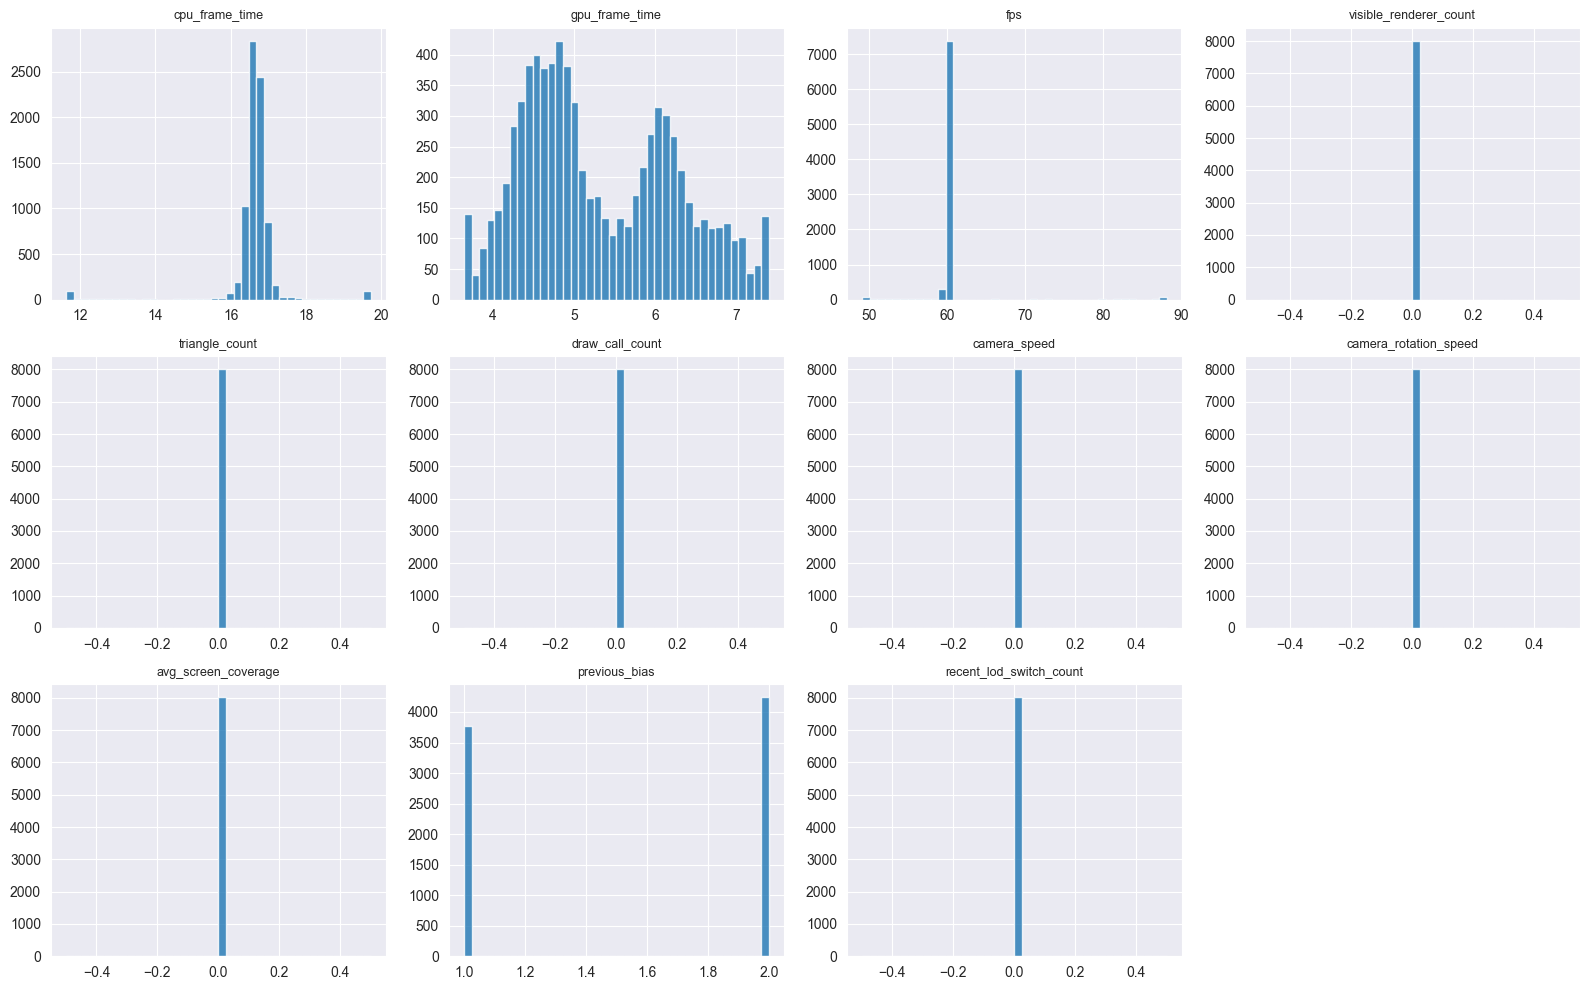

Final rows: 8013
Episodes: 2


In [7]:
# =========================
# STEP 0: FIX EPISODES (MANDATORY)
# =========================
raw = raw.copy()

if raw['episode'].isna().all():
    print("Fixing missing episode column...")
    raw['episode'] = (raw['step'] == 0).cumsum()

    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes:", raw['episode'].nunique())
print("RAW shape:", raw.shape)

# =========================
# STEP 1: INVALID FILTER
# =========================
df_clean = raw[
    (raw['gpu_frame_time'] > 0) &
    (raw['cpu_frame_time'] > 0)
].copy()

print("After invalid:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at invalid filter")

# =========================
# STEP 2: OUTLIER CLIP (NO ROW REMOVAL)
# =========================
p99 = df_clean.groupby('episode')['gpu_frame_time'].transform(lambda x: x.quantile(0.99))

print("p99 NaNs:", p99.isna().sum())

df_clean['gpu_frame_time'] = np.minimum(df_clean['gpu_frame_time'], p99)

print("After clip:", df_clean.shape)

# =========================
# STEP 3: NaN DEBUG + SAFE CLEAN
# =========================
nan_counts = df_clean[FEATURE_COLS + ['action_delta']].isna().sum()
print("\nNaN counts:")
print(nan_counts)

# drop only essential features (NOT aggressive)
df_clean = df_clean.dropna(subset=FEATURE_COLS).copy()

print("After dropna:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at NaN drop")

# =========================
# STEP 4: FINAL CHECK
# =========================
print("FINAL df_clean:", df_clean.shape)

# =========================
# STEP 5: SCALING
# =========================
X_raw = df_clean[FEATURE_COLS].values.astype(np.float32)

if X_raw.shape[0] == 0:
    raise ValueError("No samples available for scaling")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

print("Scaling OK:", X_scaled.shape)

# =========================
# STEP 6: VALIDATION
# =========================
zero_scale = [
    (name, s)
    for name, s in zip(FEATURE_COLS, scaler.scale_)
    if s < 1e-8
]

if zero_scale:
    print("WARNING zero-scale:", zero_scale)
else:
    print("All feature scales valid")

# =========================
# STEP 7: SAVE SCALER
# =========================
scaler_data = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}

scaler_path = MODEL_DIR / 'rl_scaler_constants.json'

with open(scaler_path, 'w') as f:
    json.dump(scaler_data, f, indent=2)

print("Saved:", scaler_path)

# =========================
# STEP 8: FEATURE DISTRIBUTIONS
# =========================
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    col_data = df_clean[col]

    if col_data.notna().sum() == 0:
        axes[i].set_visible(False)
        continue

    clipped = col_data.clip(
        lower=col_data.quantile(0.01),
        upper=col_data.quantile(0.99)
    )

    axes[i].hist(clipped, bins=40, alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()

# =========================
# FINAL SAFETY CHECK
# =========================
print("Final rows:", len(df_clean))
print("Episodes:", df_clean['episode'].nunique())

## 4. Reward Computation
Compute per-step proxy rewards and discounted returns for REINFORCE.

In [8]:
# =========================
# STEP: COMPUTE REWARDS (FIRST)
# =========================
gpu = df_clean['gpu_frame_time'].values
cov = df_clean['avg_screen_coverage'].values.clip(0, 1)
sw  = df_clean['recent_lod_switch_count'].values

frame_term = -ALPHA * ((gpu - T_TARGET) / T_TARGET) ** 2
qual_term  = -BETA  * (1.0 - cov)
stab_term  = -GAMMA_W * (sw / N_MAX).clip(0, 1)

rewards = (frame_term + qual_term + stab_term).astype(np.float32)

# =========================
# VALIDATION (AFTER COMPUTE)
# =========================
if len(rewards) == 0:
    raise ValueError("rewards array is empty → df_clean is empty")

if len(rewards) != len(df_clean):
    raise ValueError("Mismatch: rewards and df_clean size differ")

print(
    f'Reward stats | mean={rewards.mean():.4f} | std={rewards.std():.4f} | '
    f'min={rewards.min():.4f} | max={rewards.max():.4f}'
)

# =========================
# ATTACH TO DF
# =========================
df_clean = df_clean.copy()
df_clean['reward'] = rewards

Reward stats | mean=-0.5756 | std=0.1007 | min=-0.9424 | max=-0.5000


## 5. Policy Network
Gaussian policy MLP.  
- **Input**: 11 normalized state features  
- **Output**: action mean μ (scalar) clamped to [-0.20, +0.20]  
- **log_sigma**: global learned scalar (not part of ONNX output)  
- ONNX exports only μ — Unity reads `output[0]` as the deterministic action

In [9]:
class PolicyMLP(nn.Module):
    """Gaussian policy: outputs action mean mu in [-0.20, +0.20]."""
    def __init__(self, input_dim, h1, h2, h3, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),        nn.GELU(),
            nn.Linear(h3, 1),
            nn.Tanh()  # output in (-1, 1)
        )
        self.action_scale = 0.20  # maps tanh output → [-0.20, +0.20]
        # Global log_sigma — not exported to ONNX; used for log_prob during training only
        self.log_sigma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """Returns mu. shape: [batch, 1]"""
        return self.net(x) * self.action_scale

    def log_prob(self, x, actions):
        """Gaussian log prob for REINFORCE loss."""
        mu    = self.forward(x)  # [batch, 1]
        sigma = torch.exp(self.log_sigma).clamp(1e-4, 2.0)
        dist  = Normal(mu, sigma)
        return dist.log_prob(actions.unsqueeze(-1)).squeeze(-1)  # [batch]

print('PolicyMLP defined. Verifying output shape...')
_test = PolicyMLP(11, 256, 128, 64, 0.1)
_x    = torch.randn(4, 11)
_out  = _test(_x)
assert _out.shape == (4, 1), f'Expected (4,1) got {_out.shape}'
print(f'Output shape OK: {_out.shape} | range: [{_out.min().item():.3f}, {_out.max().item():.3f}]')

PolicyMLP defined. Verifying output shape...
Output shape OK: torch.Size([4, 1]) | range: [0.005, 0.012]


## 6. Hyperparameter Tuning (Optuna)


Reward Computation and Return Normalization

In [17]:
# =========================
# STEP: REWARD + RETURNS (REQUIRED)
# =========================
if len(df_clean) == 0:
    raise ValueError("df_clean is empty before reward computation")

# --- rewards ---
gpu = df_clean['gpu_frame_time'].values
cov = df_clean['avg_screen_coverage'].values.clip(0, 1)
sw  = df_clean['recent_lod_switch_count'].values

frame_term = -ALPHA * ((gpu - T_TARGET) / T_TARGET) ** 2
qual_term  = -BETA  * (1.0 - cov)
stab_term  = -GAMMA_W * (sw / N_MAX).clip(0, 1)

rewards = (frame_term + qual_term + stab_term).astype(np.float32)

if len(rewards) != len(df_clean):
    raise ValueError("Reward size mismatch")

df_clean = df_clean.copy()
df_clean['reward'] = rewards

# --- returns ---
def compute_returns(rewards_ep, gamma):
    G = np.zeros_like(rewards_ep)
    running = 0.0
    for t in reversed(range(len(rewards_ep))):
        running = rewards_ep[t] + gamma * running
        G[t] = running
    return G

returns_list = []
for _, grp in df_clean.groupby('episode'):
    returns_list.append(compute_returns(grp['reward'].values, GAMMA_RL))

df_clean['G_t'] = np.concatenate(returns_list)

# --- normalize ---
G_mean = df_clean['G_t'].mean()
G_std  = df_clean['G_t'].std() + 1e-8

df_clean['G_t_norm'] = (df_clean['G_t'] - G_mean) / G_std

print("Returns ready:", df_clean['G_t_norm'].shape)

Returns ready: (8013,)


Quick 10-epoch trials to find best architecture and learning rate.

In [18]:
from sklearn.model_selection import train_test_split

X_all = X_scaled
A_all = df_clean['action_delta'].values.astype(np.float32)
G_all = df_clean['G_t_norm'].values.astype(np.float32)

X_tr, X_val, A_tr, A_val, G_tr, G_val = train_test_split(
    X_all, A_all, G_all, test_size=0.15, random_state=RANDOM_SEED
)

X_tr_t  = torch.tensor(X_tr).to(device)
A_tr_t  = torch.tensor(A_tr).to(device)
G_tr_t  = torch.tensor(G_tr).to(device)
X_val_t = torch.tensor(X_val).to(device)
A_val_t = torch.tensor(A_val).to(device)
G_val_t = torch.tensor(G_val).to(device)

BATCH_SIZE = 256

def reinforce_loss(model, X, A, G):
    """REINFORCE: loss = -mean(G_t_norm * log_prob(a_t | s_t))."""
    lp   = model.log_prob(X, A)   # [batch]
    loss = -(G * lp).mean()
    return loss

def run_trial(h1, h2, h3, lr, dropout, epochs=10):
    model = PolicyMLP(FEATURE_COUNT, h1, h2, h3, dropout).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr)
    n     = len(X_tr_t)
    for _ in range(epochs):
        model.train()
        idx = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            b = idx[start:start+BATCH_SIZE]
            opt.zero_grad()
            reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    model.eval()
    with torch.no_grad():
        val_loss = reinforce_loss(model, X_val_t, A_val_t, G_val_t).item()
    return val_loss

def objective(trial):
    h1      = trial.suggest_categorical('h1',      [128, 256, 512])
    h2      = trial.suggest_categorical('h2',      [64,  128, 256])
    h3      = trial.suggest_categorical('h3',      [32,  64,  128])
    lr      = trial.suggest_float('lr',            1e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout',       0.05, 0.30)
    return run_trial(h1, h2, h3, lr, dropout)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print(f'Best val loss: {study.best_value:.6f}')
print(f'Best params:   {study.best_params}')

Best val loss: -0.012319
Best params:   {'h1': 512, 'h2': 64, 'h3': 128, 'lr': 0.004609067584707995, 'dropout': 0.1444649103127559}


## 7. Final REINFORCE Training

Epoch   0 | train=-0.0066 | val=-0.0020 | sigma=0.9941
Epoch  25 | train=-0.7601 | val=-1.1632 | sigma=0.0741
Epoch  50 | train=-4039.0612 | val=-4591.3535 | sigma=0.0012
Epoch  75 | train=-251885.2205 | val=-271207.5312 | sigma=0.0002
Epoch 100 | train=-628065.2963 | val=-631319.8125 | sigma=0.0001
Epoch 125 | train=-630997.1157 | val=-627863.1875 | sigma=0.0001


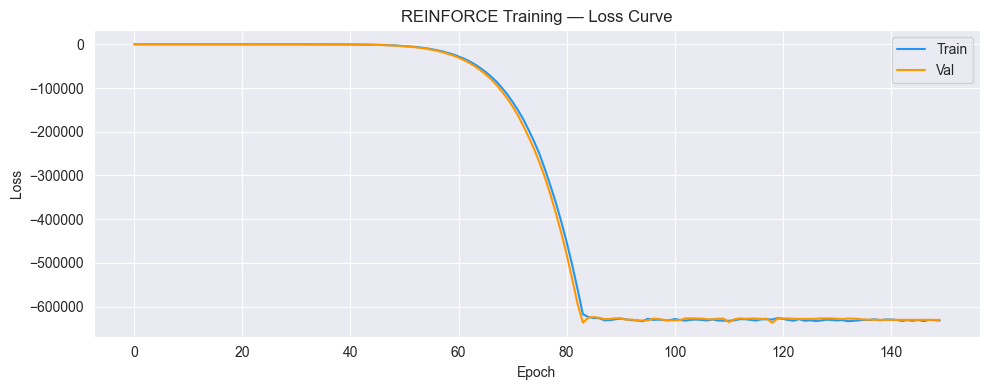

In [26]:
bp = study.best_params
model = PolicyMLP(
    FEATURE_COUNT,
    h1=bp['h1'], h2=bp['h2'], h3=bp['h3'],
    dropout=bp['dropout']
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

EPOCHS = 150
history = {'train': [], 'val': []}
n = len(X_tr_t)

for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(n)
    t_losses = []
    for start in range(0, n, BATCH_SIZE):
        b = idx[start:start+BATCH_SIZE]
        optimizer.zero_grad()
        loss = reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_losses.append(loss.item())
    scheduler.step()

    model.eval()
    with torch.no_grad():
        v_loss = reinforce_loss(model, X_val_t, A_val_t, G_val_t).item()

    history['train'].append(np.mean(t_losses))
    history['val'].append(v_loss)

    if epoch % 25 == 0:
        sigma = torch.exp(model.log_sigma).item()
        print(f'Epoch {epoch:3d} | train={np.mean(t_losses):.4f} | val={v_loss:.4f} | sigma={sigma:.4f}')

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train', color='#2196F3')
plt.plot(history['val'],   label='Val',   color='#FF9800')
plt.title('REINFORCE Training — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)
plt.show()

## 8. Policy Diagnostics

Learned sigma: 0.0001
Predicted mu   | mean=-0.0732 | std=0.1023 | min=-0.2000 | max=0.2000


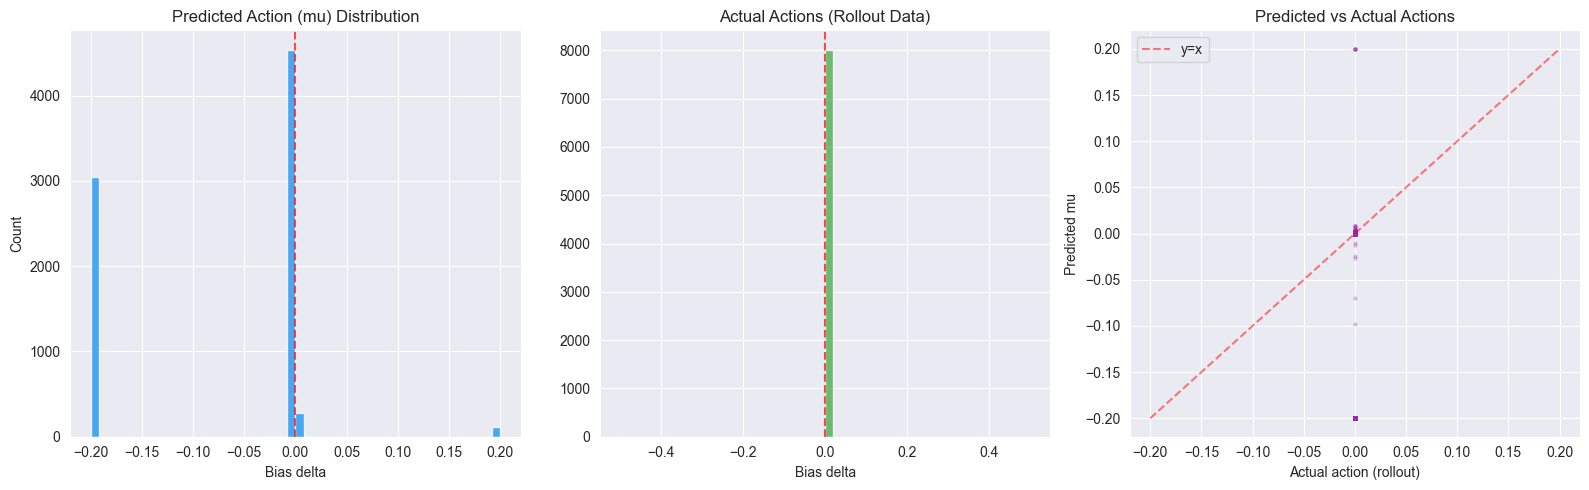

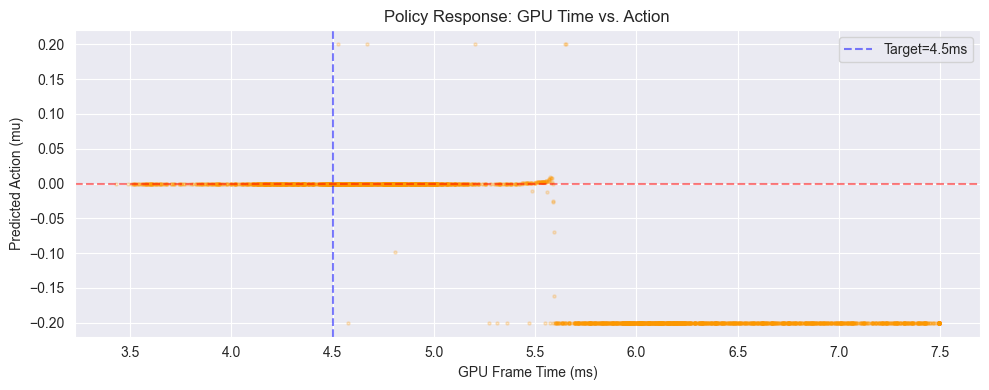

In [27]:
model.eval()
with torch.no_grad():
    mu_all = model(torch.tensor(X_scaled).to(device)).cpu().numpy().flatten()

sigma_val = torch.exp(model.log_sigma).item()
print(f'Learned sigma: {sigma_val:.4f}')
print(f'Predicted mu   | mean={mu_all.mean():.4f} | std={mu_all.std():.4f} | '
      f'min={mu_all.min():.4f} | max={mu_all.max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted action distribution
ax = axes[0]
ax.hist(mu_all, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Predicted Action (mu) Distribution')
ax.set_xlabel('Bias delta')
ax.set_ylabel('Count')

# Actual actions from rollout data
ax = axes[1]
ax.hist(A_all, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Actual Actions (Rollout Data)')
ax.set_xlabel('Bias delta')

# Predicted vs Actual scatter
ax = axes[2]
ax.scatter(A_all[:2000], mu_all[:2000], alpha=0.2, s=5, color='#9C27B0')
ax.plot([-0.2, 0.2], [-0.2, 0.2], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Actual action (rollout)')
ax.set_ylabel('Predicted mu')
ax.set_title('Predicted vs Actual Actions')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'action_diagnostics.png', dpi=150)
plt.show()

# GPU frame time vs predicted action
plt.figure(figsize=(10, 4))
plt.scatter(df_clean['gpu_frame_time'].values[:3000],
            mu_all[:3000],
            alpha=0.2, s=5, color='#FF9800')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(T_TARGET, color='blue', linestyle='--', alpha=0.5, label=f'Target={T_TARGET}ms')
plt.xlabel('GPU Frame Time (ms)')
plt.ylabel('Predicted Action (mu)')
plt.title('Policy Response: GPU Time vs. Action')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'policy_response.png', dpi=150)
plt.show()

## 9. ONNX Export
Exports `mu`-only output — Unity `RLPolicyController` reads `output[0]` as the deterministic action mean.

In [28]:
pip install onnxruntime-gpu

Note: you may need to restart the kernel to use updated packages.


In [29]:
import onnxruntime as ort
print(ort.__version__)

1.24.4


In [30]:
class PolicyMLPONNX(nn.Module):
    """Wrapper that strips log_sigma — exports only mu."""
    def __init__(self, policy):
        super().__init__()
        self.net          = policy.net
        self.action_scale = policy.action_scale

    def forward(self, x):
        return self.net(x) * self.action_scale  # [batch, 1]

export_model = PolicyMLPONNX(model).cpu().eval()
dummy_input  = torch.zeros(1, FEATURE_COUNT, dtype=torch.float32)

onnx_path = MODEL_DIR / 'rl_policy_stage4.onnx'
torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f'ONNX exported → {onnx_path}')

# Verify output shape with dummy inference
import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'input': dummy_input.numpy()})[0]
print(f'ONNX output shape: {out.shape} | value: {out[0,0]:.6f}')
assert out.shape == (1, 1), f'Expected (1,1), got {out.shape}'
print('ONNX validation OK.')
print(f'\nNext step: assign {onnx_path.name} to RLPolicyController.OnnxAsset in Unity.')

ONNX exported → C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
ONNX output shape: (1, 1) | value: -0.000003
ONNX validation OK.

Next step: assign rl_policy_stage4.onnx to RLPolicyController.OnnxAsset in Unity.


## 10. Output Summary

In [31]:
print('=== Stage 4 Training Complete ===')
print(f'  Rollout steps used  : {len(df_clean):,}')
print(f'  Episodes            : {df_clean["episode"].nunique()}')
print(f'  Feature count       : {FEATURE_COUNT}')
print(f'  Architecture        : {bp["h1"]}→{bp["h2"]}→{bp["h3"]}→1')
print(f'  Learning rate       : {bp["lr"]:.6f}')
print(f'  Final val loss      : {history["val"][-1]:.6f}')
print(f'  Learned sigma       : {torch.exp(model.log_sigma).item():.4f}')
print()
print(f'  ONNX model          : {MODEL_DIR / "rl_policy_stage4.onnx"}')
print(f'  Scaler JSON         : {MODEL_DIR / "rl_scaler_constants.json"}')
print()
print('Unity setup checklist:')
print('  1. Copy rl_scaler_constants.json → Assets/StreamingAssets/')
print('  2. Import rl_policy_stage4.onnx into Unity project')
print('  3. Assign to RLPolicyController.OnnxAsset')
print('  4. RLFeatureExtractor.scalerJsonFileName = "rl_scaler_constants.json" (default)')
print('  5. Press Play — Active Mode should show "neural" in inspector')

=== Stage 4 Training Complete ===
  Rollout steps used  : 8,013
  Episodes            : 2
  Feature count       : 11
  Architecture        : 512→64→128→1
  Learning rate       : 0.004609
  Final val loss      : -630126.937500
  Learned sigma       : 0.0001

  ONNX model          : C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
  Scaler JSON         : C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json

Unity setup checklist:
  1. Copy rl_scaler_constants.json → Assets/StreamingAssets/
  2. Import rl_policy_stage4.onnx into Unity project
  3. Assign to RLPolicyController.OnnxAsset
  4. RLFeatureExtractor.scalerJsonFileName = "rl_scaler_constants.json" (default)
  5. Press Play — Active Mode should show "neural" in inspector
